In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
ticker="TSLA"
risk_free_rate=0.05
target_Ts=[0.3,0.5,0.7,0.9,1.1]

ticker_obj=yf.Ticker(ticker)
expirations=ticker_obj.options
selected_expirations=[]
for target in target_Ts:
    available_Ts=[]
    for exp in expirations:
        days=(pd.to_datetime(exp)-pd.Timestamp.today()).days
        available_Ts.append(days/365.0)
    closest_idx=np.argmin([abs(t-target) for t in available_Ts])
    selected_expirations.append((expirations[closest_idx],available_Ts[closest_idx]))
print(selected_expirations)


[('2026-10-16', 0.28493150684931506), ('2027-01-15', 0.5342465753424658), ('2027-03-19', 0.7068493150684931), ('2027-06-17', 0.9534246575342465), ('2027-09-17', 1.2054794520547945)]


In [3]:
option_data_list=[]
for exp_date, actual_T in selected_expirations:
    opt_chain = ticker_obj.option_chain(exp_date)
    calls = opt_chain.calls

    for _, row in calls.iterrows():
        option_data_list.append({
            "K": row['strike'],
            "T": round(actual_T, 4),
            "Price": row['lastPrice']
        })
print(option_data_list)


[{'K': 50.0, 'T': 0.2849, 'Price': 333.7}, {'K': 60.0, 'T': 0.2849, 'Price': 346.91}, {'K': 75.0, 'T': 0.2849, 'Price': 276.38}, {'K': 85.0, 'T': 0.2849, 'Price': 324.6}, {'K': 90.0, 'T': 0.2849, 'Price': 324.94}, {'K': 95.0, 'T': 0.2849, 'Price': 319.82}, {'K': 100.0, 'T': 0.2849, 'Price': 307.37}, {'K': 105.0, 'T': 0.2849, 'Price': 245.45}, {'K': 110.0, 'T': 0.2849, 'Price': 264.5}, {'K': 115.0, 'T': 0.2849, 'Price': 241.4}, {'K': 120.0, 'T': 0.2849, 'Price': 233.75}, {'K': 125.0, 'T': 0.2849, 'Price': 272.97}, {'K': 130.0, 'T': 0.2849, 'Price': 286.5}, {'K': 135.0, 'T': 0.2849, 'Price': 256.09}, {'K': 140.0, 'T': 0.2849, 'Price': 205.2}, {'K': 145.0, 'T': 0.2849, 'Price': 207.8}, {'K': 150.0, 'T': 0.2849, 'Price': 236.6}, {'K': 155.0, 'T': 0.2849, 'Price': 210.65}, {'K': 160.0, 'T': 0.2849, 'Price': 199.05}, {'K': 165.0, 'T': 0.2849, 'Price': 239.53}, {'K': 175.0, 'T': 0.2849, 'Price': 249.12}, {'K': 180.0, 'T': 0.2849, 'Price': 244.28}, {'K': 185.0, 'T': 0.2849, 'Price': 238.46}, {

In [4]:
df_calibration = pd.DataFrame(option_data_list)
df_calibration.head()


,K,T,Price
0,50.0,0.2849,333.70
1,60.0,0.2849,346.91
2,75.0,0.2849,276.38
3,85.0,0.2849,324.60
4,90.0,0.2849,324.94


In [5]:
ticker_data = yf.Ticker(ticker)
recent_history = ticker_data.history(period="1d")

if not recent_history.empty:
    # The spot price is the last 'Close' price in the series
    S0 = recent_history['Close'].iloc[-1]
else:
    print(f"Warning: Could not fetch price for {ticker}")
print(S0)


393.45001220703125


In [6]:
import scipy.stats as st
from scipy.optimize import brentq

# The black-Scholes-Merton pricing model
def bs_call_price(S,K,T,r,sigma):
    if sigma<=0 or T<=0:
        return max(S-K,0)
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    return S*st.norm.cdf(d1)-K*np.exp(-r*T)*st.norm.cdf(d2)

# This function returns the implied volatility using the root finding algorithm brentq
def implied_volatility(price,S,K,T,r):
    f=lambda sigma:bs_call_price(S,K,T,r,sigma)-price
    return brentq(f,1e-6,5.0)


In [7]:
r=risk_free_rate
implied_vols = []

for index, row in df_calibration.iterrows():
    S=S0
    K, T, price = row['K'], row['T'], row['Price']

    # # Apply Strict Filtering
    # if price < 0.10:
    #     continue  # Skip unstable/illiquid data

    # Arbitrage Bound Check
    lower_bound = max(S - K * np.exp(-risk_free_rate * T), 0)
    if price <= lower_bound + 0.01 or price >= S:
        continue

    # Solve for IV
    try:
        iv = implied_volatility(price, S, K, T, risk_free_rate)
        implied_vols.append((T, K, iv))
    except ValueError:
        print("skipped")
        pass # Skip if still failing to converge
        # But as you can see nothing was skipped here because of the arbitrage bound check above

df_iv = pd.DataFrame(implied_vols, columns=['T', 'K', 'ImpliedVol'])
df_iv.head()


,T,K,ImpliedVol
0,0.2849,60.0,3.096929
1,0.2849,85.0,2.635601
2,0.2849,90.0,2.830468
3,0.2849,95.0,2.715072
4,0.2849,100.0,2.223781


In [8]:
from scipy.interpolate import RegularGridInterpolator

# points (pts) must be shape (N, 2)
pts = df_iv[['K', 'T']].values
vals = df_iv['ImpliedVol'].values

# Standardize so K and T distances are comparable inside the LOESS kernel.
_Kc, _Ks = pts[:, 0].mean(), pts[:, 0].std()
_Tc, _Ts = pts[:, 1].mean(), pts[:, 1].std()
_Kn = (pts[:, 0] - _Kc) / _Ks
_Tn = (pts[:, 1] - _Tc) / _Ts
_A = np.column_stack([np.ones(len(_Kn)), _Kn, _Tn])   # local linear design matrix

LOESS_FRAC = 0.5   # fraction of points falling inside each local neighborhood

def _loess_eval(Kq_n, Tq_n, frac=LOESS_FRAC):
    """Locally weighted linear regression at each standardized query point."""
    P = len(_Kn)
    k = min(max(int(np.ceil(frac * P)), 6), P)
    out = np.empty(len(Kq_n))
    for idx in range(len(Kq_n)):
        d = np.sqrt((_Kn - Kq_n[idx]) ** 2 + (_Tn - Tq_n[idx]) ** 2)
        h = np.partition(d, k - 1)[k - 1]              # bandwidth = distance to k-th neighbor
        h = h if h > 0 else (d.max() if d.max() > 0 else 1.0)
        w = (1 - np.clip(d / h, 0.0, 1.0) ** 3) ** 3   # tricube weights
        AW = _A * w[:, None]
        try:
            beta = np.linalg.solve(_A.T @ AW, AW.T @ vals)
            out[idx] = beta[0] + beta[1] * Kq_n[idx] + beta[2] * Tq_n[idx]
        except np.linalg.LinAlgError:
            out[idx] = (w @ vals) / w.sum()             # fall back to weighted mean
    return out

# Pre-evaluate the LOESS surface on a grid that extends beyond the quoted
# strikes/maturities so Monte Carlo excursions stay in range.
_Kg = np.linspace(pts[:, 0].min() * 0.6, pts[:, 0].max() * 1.4, 60)
_Tg = np.linspace(1e-3, pts[:, 1].max() * 1.1, 40)
_KK, _TT = np.meshgrid(_Kg, _Tg, indexing='ij')
_grid_iv = _loess_eval((_KK.ravel() - _Kc) / _Ks, (_TT.ravel() - _Tc) / _Ts)
_grid_iv = np.clip(_grid_iv.reshape(_KK.shape), 0.01, 5.0)
_loess_interp = RegularGridInterpolator((_Kg, _Tg), _grid_iv, bounds_error=False, fill_value=None)

def iv_lookup(K_query, T_query):
    K_query = np.atleast_1d(np.asarray(K_query, float))
    T_query = np.broadcast_to(np.asarray(T_query, float), K_query.shape)
    iv = _loess_interp(np.column_stack([K_query, T_query]))   # fast read-back of LOESS grid
    return np.clip(iv, 0.01, 5.0)

vol_grids = iv_lookup   # the "surface" is now the fitted LOESS model, passed to the MC engines


In [9]:
import matplotlib.pyplot as plt

def monte_carlo_vanilla(S0_scalar, K_opt, T, r, vol_surface, N_paths=20000, M_steps=250, plot_n=150):
    dt = T / M_steps
    iv_lookup = vol_surface

    S = np.full(N_paths, S0_scalar)              # one spot per Monte Carlo sample
    price_history = np.zeros((M_steps + 1, N_paths))
    price_history[0] = S0_scalar

    for step in range(M_steps):
        Z = np.random.normal(size=N_paths)       # independent draws, no correlation
        tau = T - (step * dt)                     # time-to-maturity for the vol lookup
        sigma = iv_lookup(S, tau)
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        price_history[step + 1] = S

    # Plot a subset of the simulated price paths
    time_axis = np.linspace(0, T, M_steps + 1)
    plt.figure(figsize=(12, 6))
    for p in range(min(plot_n, N_paths)):
        plt.plot(time_axis, price_history[:, p], alpha=0.4, linewidth=1)
    plt.axhline(y=K_opt, color='blue', linestyle=':', label=f'Strike Price ({K_opt:.2f})')
    plt.title(f"Monte Carlo TSLA Paths ({plot_n} samples)")
    plt.xlabel("Time (Years)")
    plt.ylabel("TSLA Price")
    plt.legend()
    plt.show()

    # Vanilla call payoff: no barrier, no basket averaging
    discounted_payoffs = np.exp(-r * T) * np.maximum(S - K_opt, 0.0)
    price = discounted_payoffs.mean()
    std_err = discounted_payoffs.std(ddof=1) / np.sqrt(N_paths)
    return price, std_err


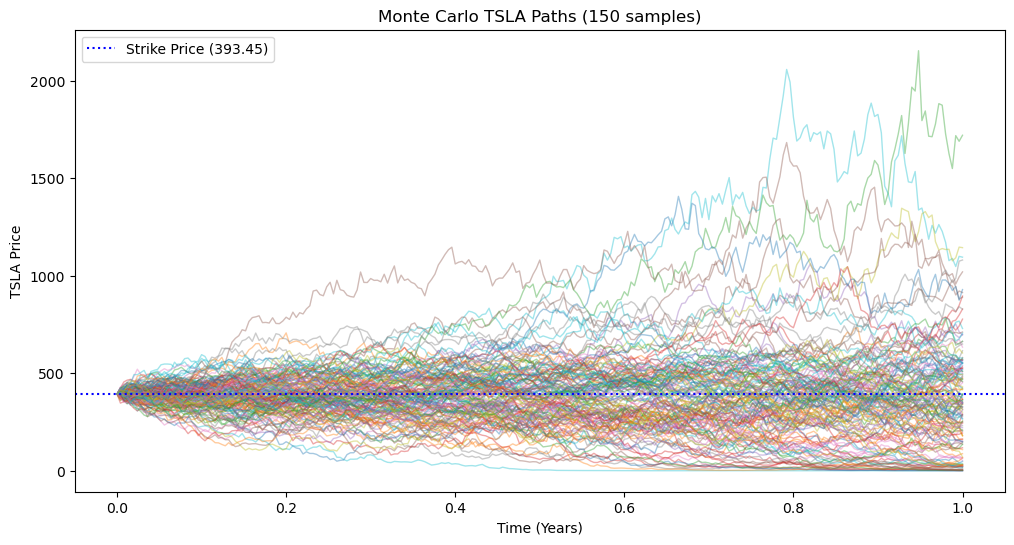

TSLA vanilla call price (K=393.45, T=1.0): 111.87 ± 2.84 (95% CI)


In [10]:
K_opt = S0        # at-the-money strike
T = 1.0           # 1 year
price, stderr = monte_carlo_vanilla(S0, K_opt, T, r, vol_grids)
print(f"TSLA vanilla call price (K={K_opt:.2f}, T={T}): {price:.2f} ± {1.96*stderr:.2f} (95% CI)")


In [11]:
sigma_atm = float(iv_lookup(K_opt, T)[0])   # iv_lookup returns an array; take the single value
bs_price = bs_call_price(S0, K_opt, T, r, sigma_atm)
print(f"Black-Scholes price (sigma={sigma_atm:.3f}): {bs_price:.2f}")


Black-Scholes price (sigma=0.585): 98.24


In [12]:
def monte_carlo_vanilla_antithetic(S0_scalar, K_opt, T, r, vol_surface, N_paths=20000, M_steps=250):
    dt = T / M_steps
    num_pairs = N_paths // 2
    iv_lookup = vol_surface

    S1 = np.full(num_pairs, S0_scalar)
    S2 = np.full(num_pairs, S0_scalar)   # antithetic twin

    for step in range(M_steps):
        Z = np.random.normal(size=num_pairs)
        tau = T - (step * dt)

        sig1 = iv_lookup(S1, tau)
        sig2 = iv_lookup(S2, tau)

        S1 *= np.exp((r - 0.5 * sig1**2) * dt + sig1 * np.sqrt(dt) * Z)
        S2 *= np.exp((r - 0.5 * sig2**2) * dt + sig2 * np.sqrt(dt) * (-Z))  # mirror

    payoff1 = np.maximum(S1 - K_opt, 0.0)
    payoff2 = np.maximum(S2 - K_opt, 0.0)
    pair_payoffs = (payoff1 + payoff2) / 2.0    # average each antithetic pair

    discounted_payoffs = np.exp(-r * T) * pair_payoffs
    price = discounted_payoffs.mean()
    std_err = discounted_payoffs.std(ddof=1) / np.sqrt(num_pairs)
    return price, std_err


In [13]:
K_opt = S0        # at-the-money strike
T = 1.0           # 1 year
price_a, stderr_a = monte_carlo_vanilla_antithetic(S0, K_opt, T, r, vol_grids)
print(f"TSLA vanilla call price (antithetic): {price_a:.2f} ± {1.96*stderr_a:.2f} (95% CI)")
print(f"Standard error  ->  plain: {stderr:.4f}   antithetic: {stderr_a:.4f}")


TSLA vanilla call price (antithetic): 114.17 ± 2.73 (95% CI)
Standard error  ->  plain: 1.4493   antithetic: 1.3923


In [14]:
eval_pool = df_calibration[
    (df_calibration['Price'] > 1.0) &
    (df_calibration['K'] >= df_iv['K'].min()) &
    (df_calibration['K'] <= df_iv['K'].max())
].drop_duplicates(subset=['K', 'T']).reset_index(drop=True)

eval_idx = np.linspace(0, len(eval_pool) - 1, 5).astype(int)   # 5 evenly spaced picks
eval_options = eval_pool.iloc[eval_idx]

model_prices, actual_prices = [], []
for _, opt in eval_options.iterrows():
    K_e, T_e, market_price = opt['K'], opt['T'], opt['Price']
    mc_price, _ = monte_carlo_vanilla_antithetic(S0, K_e, T_e, r, vol_grids)
    model_prices.append(mc_price)
    actual_prices.append(market_price)
    print(f"K={K_e:7.2f}  T={T_e:.3f}  model={mc_price:8.2f}  market={market_price:8.2f}  diff={mc_price-market_price:+7.2f}")

model_prices = np.array(model_prices)
actual_prices = np.array(actual_prices)
rmse = np.sqrt(np.mean((model_prices - actual_prices) ** 2))
print(f"\nRMSE over {len(eval_options)} options: {rmse:.4f}")


K=  50.00  T=0.285  model=  344.20  market=  333.70  diff= +10.50
K=  70.00  T=0.534  model=  326.65  market=  373.95  diff= -47.30
K= 210.00  T=0.707  model=  212.77  market=  187.75  diff= +25.02
K= 470.00  T=0.953  model=   76.33  market=   54.57  diff= +21.76
K= 880.00  T=1.206  model=   20.61  market=   15.60  diff=  +5.01

RMSE over 5 options: 26.3503
